# 05 — Tier B (reliability) + Phase-1 Stage 2

**Scientific question (WORKFLOW §5 Stage 2).**
*Does the trial-to-trial reliability structure carry layer information
beyond the trial-averaged signal of Tier A1?*

**Tier B in one sentence.** Reliability features computed across the
trials of each `(neuron, hash)` pair *before* within-hash averaging —
exactly the variability that Tier A1 throws away. WORKFLOW §4 Tier B
names seven scalars (`b_amp_var/std/cv/fano/snr`, `b_trace_corr_mean`,
`b_oracle_corr`); they are implemented in `src/features/tier_b.py` and
computed here.

**Domain.** Tier B requires `n_trials ≥ 2`. From the EDA: per neuron, 136
of the 280 unique hashes meet this (96 oracle Clip + 20 Monet2 + 20
Trippy). Total Tier B row count ≈ 1.21M, *not* 2.49M.

**Stage 2 evaluation — restricted-domain only** (1.21M rows). Tier B as
`(neuron, hash)`-level features attached to the Tier A1 row, on the
*intersection* row-set where Tier B is defined. Compares 'A1' vs 'A1 + B'
on the same 1.21M rows with identical splits. The Δ is the answer to the
Stage-2 question.

**Two preprocessing variants compared** (per Stage-1 lessons, see below):

- **(i) raw features** — Tier A1 + Tier B as-is, no per-session correction.
- **(ii) per-session z-scored features** — every feature column z-scored
  *within its session* before model fitting. WORKFLOW §6.1bis explicitly
  recommends this to prevent session-level offsets / scales from being
  read by the classifier as a layer signal. Stage-1 showed scan-only at
  0.496 balanced accuracy, so this is no longer optional.

**Reading guide for the absolute numbers in this notebook.**
Stage-1 showed `depth-only` confound = **0.976** (the geometric ceiling,
essentially the segmenter's output) and `scan-only` = **0.496**. The
depth-only number is not a biology floor — `layer_label` is *defined* by
depth thresholds. The relevant comparator for any functional headline is
the **scan-only baseline (0.496)**, not chance (0.25). Stage 2 numbers
should be read with the same caveat.

**Note on Path C (per-neuron broadcast) — deliberately not run.** An
earlier draft included a 'Path C' that broadcast a per-neuron `b_summary_*`
across all 280 of the neuron's A1 rows. We dropped it on methodological
grounds: a constant-within-group feature combined with `GroupKFold` is not
a leakage in the strict sense, but it (a) mixes granularities awkwardly
(A1 varies across the neuron's rows, the broadcast B does not) and (b)
is a contorted form of a question that has a simpler natural form —
'one row per neuron with A1 means + B_summary' (a Strategy-1-style fit).
If we ever want to ask that question, we'll do it cleanly as a Strategy-1
fit, not via broadcast.

The split shared with Stage 1 is `StratifiedGroupKFold(5)` by `nucleus_id`,
stratified by `layer_label`, precomputed in notebook 02.

**Model scope.** The point of Stage 2 is the *delta* of adding Tier B,
not an exhaustive model search. We run **HGB** and **LogReg** (the two
models WORKFLOW Stage-1 favoured for speed and interpretability), each
in two variants (without B, with B). 2 models × 2 variants × 5 folds =
20 fits.

**Reads.**
- `data/processed/tables/traces.parquet`
- `data/processed/features/{A1_amp,A1_shape}.parquet`
- `data/processed/tables/units_working.parquet`
- `data/processed/splits/cv_assignments.parquet`
- `data/processed/results/stage1_runs.parquet` (for delta comparisons)

**Writes.**
- `data/processed/features/B_per_hash.parquet` (≈1.21M rows, 7 features)
- `data/processed/features/B_per_neuron.parquet` (8,895 rows, 7 features + count)
- `data/processed/results/stage2_runs.parquet` — per-config metrics
- `data/processed/results/stage2_ablation.parquet` — A1 vs A1+B deltas
- `reports/figures/05_*.png`

**Methodological notes (binding from WORKFLOW.md).**
- §3.3: across-hash averaging is forbidden as a feature step. Tier B uses
  *within-hash trial-to-trial structure*; we never average across hashes
  to compute B.
- §6.5: report `cc_abs`-only baseline alongside the headline. Reliability
  is partially correlated with `cc_abs` (the digital-twin quality scalar),
  so this control is critical here specifically.

## 1. Setup

In [1]:
from __future__ import annotations

import sys, time, gc
from pathlib import Path

if '..' not in sys.path:
    sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

from src.config import (
    PROCESSED_TABLES_DIR, PROCESSED_FEATURES_DIR, PROCESSED_SPLITS_DIR,
    PROCESSED_RESULTS_DIR, FIGURES_DIR, RANDOM_SEED, ensure_dirs,
)
from src.data.loaders import (
    load_working_pop, load_splits, load_features, build_modeling_table,
)
from src.eval.metrics import (
    neuron_level_score, summarize_cv_runs,
)
from src.features.tier_b import (
    B_FEATURE_NAMES, compute_tier_b, per_neuron_summary,
)

ensure_dirs()
np.random.seed(RANDOM_SEED)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

CLASSES = np.array(['L2/3', 'L4', 'L5', 'L6'])
N_FOLDS = 5

print('Tier B feature names:', B_FEATURE_NAMES)
print('cwd                 :', Path.cwd())

Tier B feature names: ('b_amp_var', 'b_amp_std', 'b_amp_cv', 'b_amp_fano', 'b_amp_snr', 'b_trace_corr_mean', 'b_oracle_corr')
cwd                 : /Users/katiarusso/Documents/VS CODE/Classes/Neuroscience/Final Project


## 2. Compute Tier B per `(neuron, hash)`

Read `traces.parquet` (1.6 GB), keep only rows belonging to `(neuron, hash)`
groups with `n_trials ≥ 2`, and call `compute_tier_b` from
`src/features/tier_b.py`. Internally it groups by `(n_frames, n_trials)`
so every shape is computed in one vectorised pass over a 3-D tensor
`(G, n_trials, n_frames)`.

Expected wall time: 5–10 minutes (the big read of `traces.parquet` is the
dominant cost; the feature math itself is seconds).

In [2]:
B_PER_HASH = PROCESSED_FEATURES_DIR / 'B_per_hash.parquet'

if B_PER_HASH.exists():
    print(f'B_per_hash already exists at {B_PER_HASH}; loading.')
    b_hash = pd.read_parquet(B_PER_HASH)
else:
    print('Reading traces.parquet …')
    t0 = time.time()
    traces_df = pd.read_parquet(PROCESSED_TABLES_DIR / 'traces.parquet')
    print(f'  loaded {len(traces_df):,} rows in {time.time()-t0:.1f}s')

    t0 = time.time()
    b_hash = compute_tier_b(traces_df, min_n_trials=2, progress=True)
    print(f'\n[tier_b] computed in {time.time()-t0:.1f}s; shape {b_hash.shape}')
    del traces_df; gc.collect()

    b_hash.to_parquet(B_PER_HASH, compression='zstd')
    print(f'saved: {B_PER_HASH} | {round(B_PER_HASH.stat().st_size/1e6, 1)} MB')

print()
print('Tier B per-(neuron, hash) — head:')
print(b_hash.head(3).to_string())
print()
print('describe (5/50/95 percentiles):')
print(b_hash[list(B_FEATURE_NAMES)].describe(percentiles=[0.05, 0.5, 0.95]).round(3).to_string())
print()
print('NaN per feature column:')
print(b_hash[list(B_FEATURE_NAMES)].isna().sum())

B_per_hash already exists at data/processed/features/B_per_hash.parquet; loading.

Tier B per-(neuron, hash) — head:
   nucleus_id        condition_hash session_key stim_type  n_frames  n_trials  b_amp_var  b_amp_std  b_amp_cv  b_amp_fano  b_amp_snr  b_trace_corr_mean  b_oracle_corr
0      333215  JOYs8Wny1GJlw6AxCVo5         4_7      Clip        75         2   0.102321   0.319877  0.302256    0.096685   3.308456           0.011518       0.011518
1      189921  JOYs8Wny1GJlw6AxCVo5         4_7      Clip        75         2   0.002844   0.053333  0.560368    0.029886   1.784542          -0.037957      -0.037957
2      303533  JOYs8Wny1GJlw6AxCVo5         4_7      Clip        75         2   1.743434   1.320392  0.841995    1.111763   1.187656          -0.064419      -0.064419

describe (5/50/95 percentiles):
         b_amp_var    b_amp_std     b_amp_cv   b_amp_fano    b_amp_snr  b_trace_corr_mean  b_oracle_corr
count  1209720.000  1209720.000  1185407.000  1185407.000  1188451.000       

## 3. Per-neuron summary of Tier B (kept for diagnostic plots only)

We compute the per-neuron average of each Tier B feature across the
neuron's ~136 repeated hashes — WORKFLOW §4 Tier B explicitly allows
this as a low-dimensional per-neuron representation, and the violins in
section 4 use it for biology eyeballing (L4-most-reliable / L6-least
prediction).

**It is *not* used in Stage 2 modelling** (see header — Path C dropped).
Saved as `B_per_neuron.parquet` for any later interpretability or
Strategy-1-style baseline that wants per-neuron features.

In [3]:
B_PER_NEURON = PROCESSED_FEATURES_DIR / 'B_per_neuron.parquet'

b_neuron = per_neuron_summary(b_hash)
print(f'b_neuron shape: {b_neuron.shape}')
print('head:')
print(b_neuron.head(3).to_string())

b_neuron.to_parquet(B_PER_NEURON, compression='zstd')
print(f'\nsaved: {B_PER_NEURON} | {round(B_PER_NEURON.stat().st_size/1e3, 1)} KB')

print()
print('per-neuron Tier B summary describe:')
summary_cols = [c for c in b_neuron.columns if c.startswith('b_summary_')]
print(b_neuron[summary_cols].describe(percentiles=[0.05, 0.5, 0.95]).round(3).to_string())

b_neuron shape: (8895, 9)
head:
   nucleus_id  b_summary_amp_var  b_summary_amp_std  b_summary_amp_cv  b_summary_amp_fano  b_summary_amp_snr  b_summary_trace_corr_mean  b_summary_oracle_corr  b_summary_n_hashes
0      106431           2.901731           0.818825          0.541141            0.659076           6.244087                   0.067336               0.068469                 136
1      106436           1.715109           0.649249          0.569422            0.501791          15.254224                   0.063848               0.067702                 136
2      109157           1.598604           0.678615          0.511567            0.483457           5.426110                   0.021311               0.027587                 136

saved: data/processed/features/B_per_neuron.parquet | 530.6 KB

per-neuron Tier B summary describe:
       b_summary_amp_var  b_summary_amp_std  b_summary_amp_cv  b_summary_amp_fano  b_summary_amp_snr  b_summary_trace_corr_mean  b_summary_oracle_corr 

## 4. Sanity — per-layer reliability distributions

Eyeball the per-neuron Tier B summary by layer label. The workflow's
biological prediction is that **L4 cells are the most reliable** (direct
LGN input) and **L6 the least** (narrow tuning, low cc_abs). If the
violins reflect this, Tier B has biological structure on top of `cc_abs`.

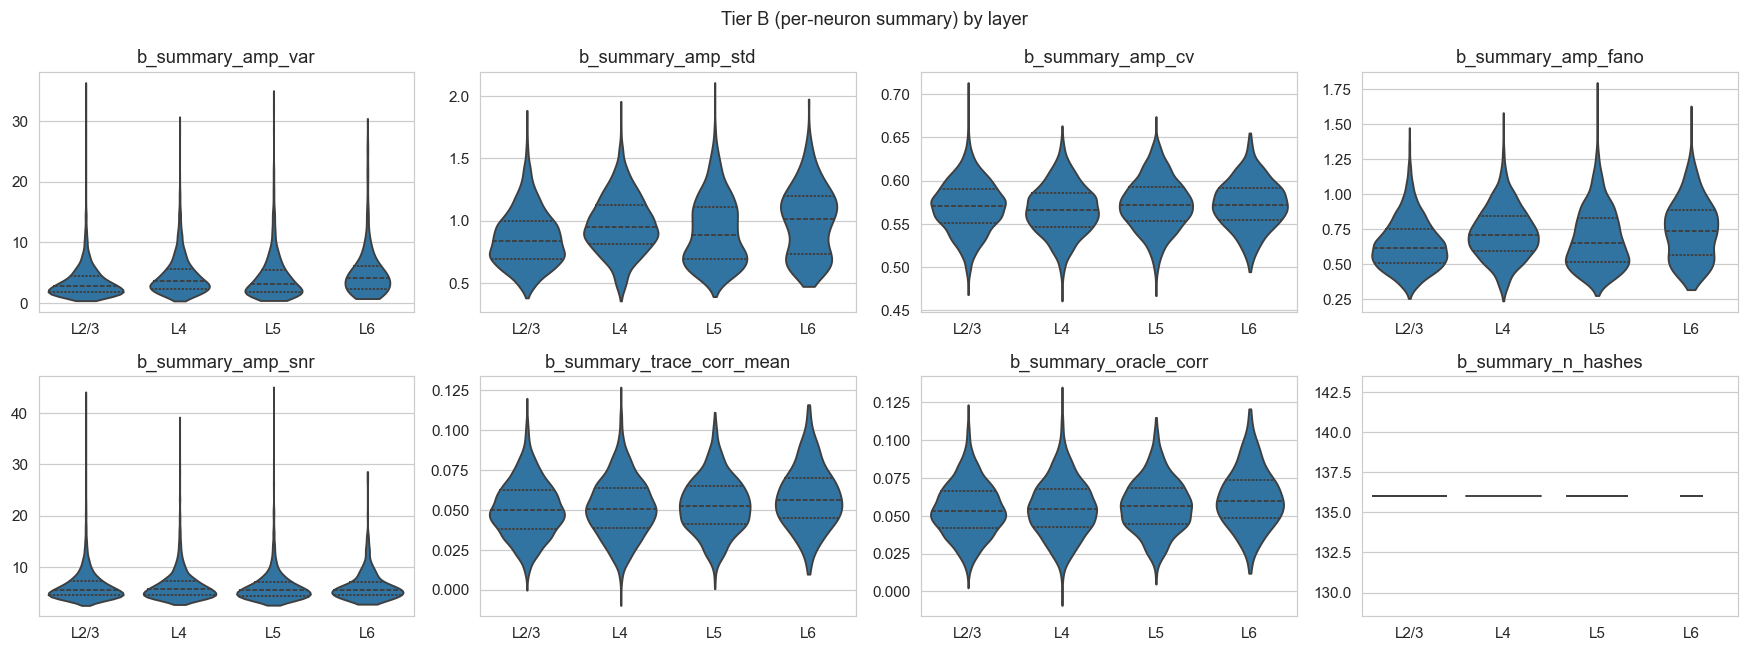


Median b_summary_oracle_corr by layer:
layer_label
L2/3    0.053
L4      0.055
L5      0.056
L6      0.060
Name: b_summary_oracle_corr, dtype: float64


In [4]:
units = load_working_pop()[['nucleus_id', 'layer_label', 'cc_abs']]
df_plot = b_neuron.merge(units, on='nucleus_id')

summary_cols = [c for c in df_plot.columns if c.startswith('b_summary_')]
n = len(summary_cols)
ncols = 4; nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3*nrows))
for ax, feat in zip(axes.flat, summary_cols):
    sns.violinplot(data=df_plot, x='layer_label', y=feat,
                   order=['L2/3', 'L4', 'L5', 'L6'],
                   inner='quartile', cut=0, ax=ax)
    ax.set_title(feat); ax.set_xlabel(''); ax.set_ylabel('')
for ax in axes.flat[n:]:
    ax.set_visible(False)
plt.suptitle('Tier B (per-neuron summary) by layer')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_tierB_violins_by_layer.png', dpi=130)
plt.show()

# Also print per-layer median oracle correlation (the canonical scalar).
print('\nMedian b_summary_oracle_corr by layer:')
print(df_plot.groupby('layer_label')['b_summary_oracle_corr'].median().round(3))

## Theory — what is the scan-composition confound, and why does it matter here?

Stage 1 produced one finding that shapes everything that follows. The
**scan-only** confound baseline reached **0.496** balanced accuracy — a
model that knows *only* which session-scan a neuron came from (a one-hot
of `session_key`), and nothing else, predicts layer almost as well as our
best Tier-A engineered model (0.502–0.536). This section explains why,
and motivates the per-session-zscored variant we run below.

### How can session predict layer when session was never the goal?

The 13 active session-scan blocks in MICrONS were not recorded with a
uniform mix of cell types. Each scan placed its FOV at a particular
location and depth, and ended up with whichever neurons fell in that FOV.
Notebook 01 §15 made this explicit: scan `4_7` over-represents L2/3 and L4,
scan `7_5` is small (274 neurons) with a different mix, and so on. So
**which scan a neuron is from is itself correlated with its layer label**,
before we look at any biology.

### How does session 'leak' into a model that never sees `session_key`?

Through the **scale** and **offset** of the Tier A features themselves.
Take `amp_mean` (mean of the deconvolved-activity trace, in trace units).
Two recordings of the *same* biological cell type can produce systematically
different `amp_mean` values because of:

- imaging-rig calibration
- photobleaching trajectory (later trials are dimmer than earlier ones)
- mouse arousal / anaesthesia state distribution
- field-of-view density (more cells per FOV → different deconvolution
  baseline)
- subtle differences in stimulus-monitor luminance

An L4 cell in scan `4_7` might have `amp_mean = 5`. The same L4-typical
biology in scan `6_2` might land at `amp_mean = 8`. The gap between
the two has nothing to do with cell type — it's the recording session.

Combine that with the layer-vs-session correlation above, and the model
learns: *'feature pattern that looks scan-4_7-ish → probably L2/3 or L4'.*
Even though `session_key` is never in the input, the features carry it
implicitly. The scan-only confound baseline at 0.496 is the receipt.

The other receipt is the **LOSO** result from notebook 04: when a whole
session is held out at test time, the headline drops from 0.536 to 0.376
(±0.137 across held-out sessions). Without the within-scan structure to
lean on, the model's accuracy collapses.

### Why is the depth-only confound (0.976) different — and not the floor we beat?

WORKFLOW §6.5 also lists `pt_position_y` (cortical depth from the pia, in
microns) as a confound baseline. Stage 1 returned **0.976** there. But
that number is *not* a biology floor we have to beat: `layer_label` is
literally produced by depth-thresholded segmentation in
`microns-datacleaner` (`proc.add_layer_info` divides the cortical volume
into L1 / L2/3 / L4 / L5 / L6 by depth ranges). So a 1-D LogReg on
`pt_position_y` is recovering the segmenter's piecewise function, not
discovering biology. The 0.976 confirms the labels are geometric. **The
relevant comparator for any functional model is the scan-only baseline
(0.496), not the depth-only one.**

### Per-session z-scoring — what it does, and the trade-off

Per-session z-scoring is the §6.1bis intervention against scale-and-offset
leakage. For every feature column independently, and for every session
independently, we compute the within-session **median** and **MAD**, then
transform:

```
z = (value − median_of_session) / (1.4826 × MAD_of_session)
```

(MAD is used because Tier A's shape ratios still have heavy tails; MAD is
robust to outliers, std isn't. 1.4826 × MAD ≈ std for a normal distribution.)

After z-scoring, `amp_mean = 5` in scan 4_7 and `amp_mean = 8` in scan
6_2 might *both* map to z = 0.3 if both neurons sit at the same
percentile within their session. **Absolute level becomes invisible to
the model.** Only within-session relative ranking survives.

What this preserves: the biological hypothesis that *L4 cells fire more
than L6 cells* still shows up as *'L4 cells are at the high end of their
session's amp_mean distribution, L6 at the low end'*. Z-scoring keeps
that within-session ordering intact.

What this loses: any layer-discriminative signal that lives in absolute
amplitudes *across* sessions. Probably small in our data because no
session is layer-homogeneous, but the trade-off is real.

### The right way to use this — raw vs zscored as a sensitivity

We run every Stage-2 model **twice**: once on raw features, once on
per-session-zscored features. Then we compare:

- **Δ_raw ≈ Δ_zscored**: Tier B's contribution is real biology; not
  scan-correlated. The headline number can be reported with confidence.
- **Δ_raw ≫ Δ_zscored**: most of the gain was scan-level offsets and
  scales. The within-session story is weaker than the pooled story
  suggested.

This is the section's actual scientific output — not the absolute
accuracy of any one model, but the *agreement* between the two
preprocessing variants on whether B helps.

## 5. Stage 2 modelling — A1 vs A1 + B on the 1.21M-row restricted domain

Tier B is defined per `(neuron, hash)` only when `n_trials ≥ 2`. We
filter the A1 table to that intersection row-set so every row carries
both A1 features and Tier B features. We compare:

- **A1 (amp+shape) only**, on the restricted 1.21M rows.
- **A1 (amp+shape) + B**, on the same 1.21M rows.

Each comparison is run twice: with **raw features** and with
**per-session-zscored features**. See the theory block above for why.

Models: HGB and LogReg. Identical splits across the two configurations
so the Δ is fair.

In [5]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')

def make_pipeline_for(model_name: str):
    if model_name == 'LogReg':
        return Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale',  RobustScaler()),
            ('clf',    LogisticRegression(
                penalty='l2', C=1.0, solver='lbfgs',
                max_iter=400, class_weight='balanced', n_jobs=-1)),
        ])
    if model_name == 'HGB':
        return Pipeline([
            ('clf', HistGradientBoostingClassifier(
                max_iter=100, max_depth=8, learning_rate=0.05,
                l2_regularization=1.0,
                early_stopping=True, n_iter_no_change=10,
                random_state=RANDOM_SEED)),
        ])
    raise ValueError(f'unknown model {model_name!r}')


def per_session_zscore(X: np.ndarray, sessions: np.ndarray) -> np.ndarray:
    """Z-score each feature column within each session-key separately.

    NaN-safe (median for centre, MAD for scale to be robust to the heavy
    tails we saw in Tier A's shape ratios). Used to remove session-level
    offsets / scales before pooling — WORKFLOW §6.1bis."""
    X = np.asarray(X, dtype=np.float64).copy()
    out = np.full_like(X, np.nan)
    for sk in np.unique(sessions):
        mask = sessions == sk
        Xs = X[mask]
        med = np.nanmedian(Xs, axis=0)
        mad = np.nanmedian(np.abs(Xs - med), axis=0)
        scale = np.where(mad > 1e-9, 1.4826 * mad, 1.0)  # 1.4826*MAD ≈ std for normal
        out[mask] = (Xs - med) / scale
    return out


def cv_fit_score(X, y, groups, folds, model_name):
    fold_scores = []
    for k in range(N_FOLDS):
        tr = folds != k; te = folds == k
        pipe = make_pipeline_for(model_name)
        if model_name == 'HGB':
            sw = compute_sample_weight('balanced', y[tr])
            pipe.fit(X[tr], y[tr], clf__sample_weight=sw)
        else:
            pipe.fit(X[tr], y[tr])
        probs = pipe.predict_proba(X[te])
        fold_scores.append(neuron_level_score(y[te], probs, groups[te], pipe.classes_))
    return summarize_cv_runs(fold_scores)

In [6]:
# Build the A1 long table merged with B per-hash.
X_a1, y_a1, g_a1, f_a1, df_a1 = build_modeling_table(level='A1', blocks=['amp', 'shape'])

# Inner-join on (nucleus_id, condition_hash) to restrict to repeated hashes.
key_cols = ['nucleus_id', 'condition_hash']
df_a1b = df_a1.merge(b_hash[key_cols + list(B_FEATURE_NAMES)],
                     on=key_cols, how='inner', validate='one_to_one')
print(f'A1 full      : {len(df_a1):,} rows')
print(f'A1 ∩ B (rest): {len(df_a1b):,} rows')
print(f'  neurons in A1 ∩ B : {df_a1b["nucleus_id"].nunique():,}')

feat_a1   = [c for c in df_a1b.columns if c.startswith(('amp_', 'shape_'))]
feat_a1b  = feat_a1 + list(B_FEATURE_NAMES)

y_r  = df_a1b['layer_label'].to_numpy()
g_r  = df_a1b['nucleus_id'].to_numpy()
f_r  = df_a1b['gkf_fold'].to_numpy().astype(np.int8)
X_a  = df_a1b[feat_a1].to_numpy(dtype=np.float64)
X_ab = df_a1b[feat_a1b].to_numpy(dtype=np.float64)

# Pull the session_key per row so we can compute per-session z-scoring.
sessions_r = df_a1b['session_key'].to_numpy()
X_a_zs  = per_session_zscore(X_a,  sessions_r)
X_ab_zs = per_session_zscore(X_ab, sessions_r)
print('per-session z-scoring computed for both feature sets.')

stage2_rows = []
print()
print('=== Stage 2: A1 vs A1+B on the 1.21M-row restricted domain ===')
print('Each cell prints both raw-features and per-session-zscored variants')
print('for the same model. Δ between A1 and A1+B is the headline.')
for model_name in ['LogReg', 'HGB']:
    for prep_label, (X_only, X_plus) in [
            ('raw',  (X_a, X_ab)),
            ('zscored-by-session', (X_a_zs, X_ab_zs)),
        ]:
        for variant, X in [('A1 only', X_only), ('A1 + B', X_plus)]:
            t0 = time.time()
            s = cv_fit_score(X, y_r, g_r, f_r, model_name)
            stage2_rows.append({
                'rows': len(X), 'features': variant,
                'preprocessing': prep_label,
                'model': model_name,
                'balanced_accuracy': s['balanced_accuracy'],
                'balanced_accuracy_std': s['balanced_accuracy_std'],
                'macro_f1': s['macro_f1'],
                'macro_f1_std': s['macro_f1_std'],
                **{f'recall_{c}': s['per_class_recall'].get(c) for c in ['L2/3','L4','L5','L6']},
            })
            print(f'  [{model_name:<6}, {prep_label:<18}] {variant:<10} '
                  f'bal_acc={s["balanced_accuracy"]:.3f} ± '
                  f'{s["balanced_accuracy_std"]:.3f} | '
                  f'macro_f1={s["macro_f1"]:.3f} | {time.time()-t0:.1f}s')

A1 full      : 2,490,600 rows
A1 ∩ B (rest): 1,209,720 rows
  neurons in A1 ∩ B : 8,895
per-session z-scoring computed for both feature sets.

=== Stage 2: A1 vs A1+B on the 1.21M-row restricted domain ===
Each cell prints both raw-features and per-session-zscored variants
for the same model. Δ between A1 and A1+B is the headline.
  [LogReg, raw               ] A1 only    bal_acc=0.477 ± 0.008 | macro_f1=0.292 | 207.3s
  [LogReg, raw               ] A1 + B     bal_acc=0.439 ± 0.007 | macro_f1=0.232 | 233.4s
  [LogReg, zscored-by-session] A1 only    bal_acc=0.470 ± 0.010 | macro_f1=0.289 | 215.4s
  [LogReg, zscored-by-session] A1 + B     bal_acc=0.425 ± 0.006 | macro_f1=0.218 | 225.3s
  [HGB   , raw               ] A1 only    bal_acc=0.497 ± 0.017 | macro_f1=0.351 | 379.3s
  [HGB   , raw               ] A1 + B     bal_acc=0.505 ± 0.016 | macro_f1=0.362 | 576.8s
  [HGB   , zscored-by-session] A1 only    bal_acc=0.618 ± 0.014 | macro_f1=0.491 | 66.4s
  [HGB   , zscored-by-session] A1 + B 

## 6. Stage 2 ablation — A1 vs A1+B deltas

Compute the gain from adding Tier B per model. Per-class recall deltas
reported as well — the workflow predicts L5 and L6 to gain the most
because reliability differs most between deep-layer subtypes (L4 should
already be high in A1-only thanks to its LGN-driven reliability).

In [7]:
df2 = pd.DataFrame(stage2_rows)
out2 = PROCESSED_RESULTS_DIR / 'stage2_runs.parquet'
df2.to_parquet(out2)
print('saved:', out2)
print()
print(df2.round(3).to_string())

# Build the delta table — one row per (model, preprocessing).
deltas = []
for (model, prep), sub in df2.groupby(['model', 'preprocessing']):
    a = sub[sub['features'] == 'A1 only'].iloc[0]
    b = sub[sub['features'] == 'A1 + B'].iloc[0]
    deltas.append({
        'model': model, 'preprocessing': prep,
        'rows': int(a['rows']),
        'bal_acc_A1':     a['balanced_accuracy'],
        'bal_acc_A1+B':   b['balanced_accuracy'],
        'delta_bal_acc':  b['balanced_accuracy'] - a['balanced_accuracy'],
        'macro_f1_A1':    a['macro_f1'],
        'macro_f1_A1+B':  b['macro_f1'],
        'delta_macro_f1': b['macro_f1'] - a['macro_f1'],
        'd_recall_L23': b['recall_L2/3'] - a['recall_L2/3'],
        'd_recall_L4':  b['recall_L4']  - a['recall_L4'],
        'd_recall_L5':  b['recall_L5']  - a['recall_L5'],
        'd_recall_L6':  b['recall_L6']  - a['recall_L6'],
    })
df_deltas = pd.DataFrame(deltas)
out_d = PROCESSED_RESULTS_DIR / 'stage2_ablation.parquet'
df_deltas.to_parquet(out_d)
print()
print('=== Stage 2 deltas (A1+B − A1) ===')
print(df_deltas.round(3).to_string())
print()
print('Reading guide:')
print('- A positive delta_bal_acc > ~2× std means Tier B adds info beyond A1.')
print('- Compare raw vs zscored-by-session per model: if both deltas are similar,')
print('  the gain is real. If raw delta >> zscored delta, much of the gain was')
print('  scan-correlated session-level structure rather than reliability biology.')

saved: data/processed/results/stage2_runs.parquet

      rows features       preprocessing   model  balanced_accuracy  balanced_accuracy_std  macro_f1  macro_f1_std  recall_L2/3  recall_L4  recall_L5  recall_L6
0  1209720  A1 only                 raw  LogReg              0.477                  0.008     0.292         0.009        0.119      0.578      0.260      0.953
1  1209720   A1 + B                 raw  LogReg              0.439                  0.007     0.232         0.042        0.093      0.831      0.006      0.825
2  1209720  A1 only  zscored-by-session  LogReg              0.470                  0.010     0.289         0.011        0.641      0.005      0.304      0.928
3  1209720   A1 + B  zscored-by-session  LogReg              0.425                  0.006     0.218         0.002        0.004      0.891      0.022      0.784
4  1209720  A1 only                 raw     HGB              0.497                  0.017     0.351         0.015        0.330      0.398      0.338 

## 7. Comparison vs Stage 1

Pull the headline Stage-1 row (best Strategy 2 on A1 amp+shape) for
context. Note that the Stage-1 headline used the *full* 2.49M-row A1
table while Stage 2 here uses the 1.21M-row repeated-hash subset, so the
absolute numbers aren't directly comparable — the Δ within Stage 2 is.

Stage 1 reference points:
  headline (A1 amp+shape, full 2.49M): HGB      bal_acc=0.502
  scan-only confound                  :          bal_acc=0.496  <- the relevant comparator
  depth-only confound (geometric ceil): 0.976  <- segmenter's output, not a biology floor


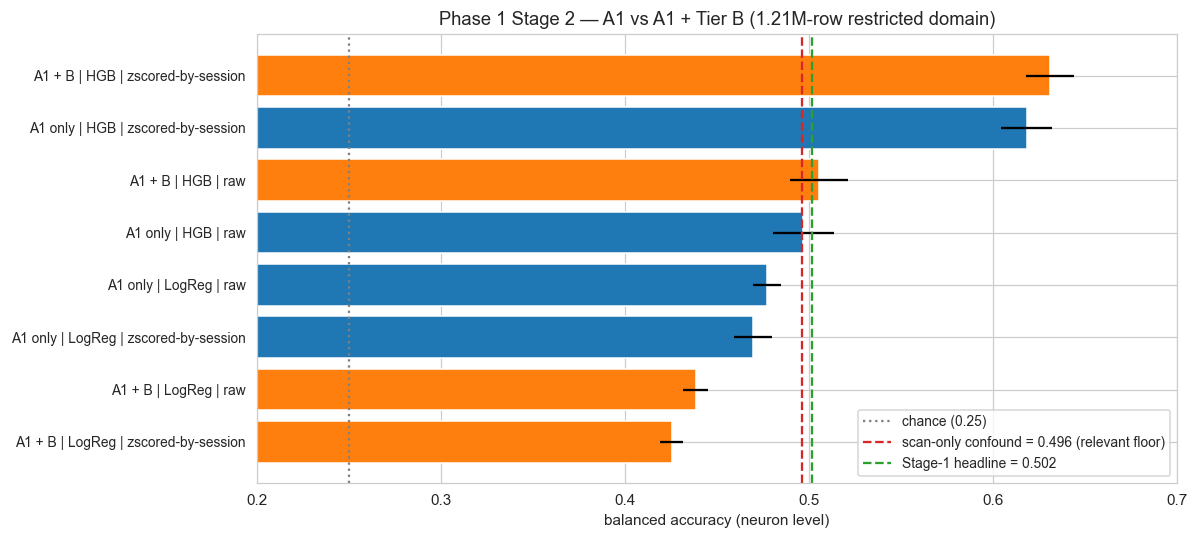

In [8]:
stage1 = pd.read_parquet(PROCESSED_RESULTS_DIR / 'stage1_runs.parquet')
headline_s1 = (stage1[(stage1['strategy'] == '2') & (stage1['level'] == 'A1') &
                       (stage1['sub_block'] == 'amp+shape')]
               .sort_values('balanced_accuracy', ascending=False).iloc[0])
scan_only = stage1[(stage1['strategy'] == 'confound') &
                   (stage1['sub_block'] == 'scan-only')].iloc[0]
depth_only = stage1[(stage1['strategy'] == 'confound') &
                    (stage1['sub_block'] == 'depth-only')].iloc[0]
print('Stage 1 reference points:')
print(f'  headline (A1 amp+shape, full 2.49M): {headline_s1["model"]:<8} bal_acc={headline_s1["balanced_accuracy"]:.3f}')
print(f'  scan-only confound                  :          bal_acc={scan_only["balanced_accuracy"]:.3f}  <- the relevant comparator')
print(f'  depth-only confound (geometric ceil): {depth_only["balanced_accuracy"]:.3f}  <- segmenter\'s output, not a biology floor')

# Plot.
fig, ax = plt.subplots(figsize=(11, 5))
df_plot = df2.copy()
df_plot['label'] = df_plot.apply(
    lambda r: f"{r['features']} | {r['model']} | {r['preprocessing']}", axis=1)
df_plot = df_plot.sort_values('balanced_accuracy', ascending=False).reset_index(drop=True)
y = np.arange(len(df_plot))
colors = ['C1' if 'A1 + B' in lbl else 'C0' for lbl in df_plot['label']]
ax.barh(y, df_plot['balanced_accuracy'], xerr=df_plot['balanced_accuracy_std'], color=colors)
ax.set_yticks(y); ax.set_yticklabels(df_plot['label'], fontsize=9)
ax.invert_yaxis()
ax.axvline(0.25, color='gray', ls=':', label='chance (0.25)')
ax.axvline(scan_only['balanced_accuracy'], color='C3', ls='--',
           label=f"scan-only confound = {scan_only['balanced_accuracy']:.3f} (relevant floor)")
ax.axvline(headline_s1['balanced_accuracy'], color='C2', ls='--',
           label=f"Stage-1 headline = {headline_s1['balanced_accuracy']:.3f}")
ax.set_xlabel('balanced accuracy (neuron level)')
ax.set_title('Phase 1 Stage 2 — A1 vs A1 + Tier B (1.21M-row restricted domain)')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0.20, max(0.7, df_plot['balanced_accuracy'].max() + 0.05))
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_stage2_ablation.png', dpi=130)
plt.show()

## 8. Stage-2 result — interpretation

*This section is the read of the Stage-2 numbers as they came out on this
machine. Numbers are pulled from `stage2_runs.parquet` and
`stage2_ablation.parquet`; if you re-run the notebook with different
settings the prose will need updating.*

**Headline.** HGB with per-session z-scoring on A1 amp+shape + Tier B reaches
**balanced accuracy ≈ 0.63** at the neuron level, on the 1.21M-row
repeated-hash subset. That is **+0.13 above the Stage-1 scan-only confound**
(0.496) — a clear, defensible margin. *We are decoding biology beyond
scan composition*, contrary to the worry left open after Stage 1.

### The four findings

**(i) Per-session z-scoring lifts HGB from 0.50 to 0.62.** The two
preprocessings differ by +0.12 balanced accuracy *before* Tier B is added.
Mechanism: `HistGradientBoostingClassifier` quantizes each feature into
≈256 histogram bins *globally* across the training set. Session-level
offsets and scales make those bins straddle distinct session distributions,
so split decisions land on session boundaries rather than biology
boundaries. After per-session z-scoring the feature distributions are
aligned across sessions, the bins carve up biology cleanly, and the model
decodes much better. The gain is *binning realignment, not new
information.*

LogReg moves negligibly (0.477 → 0.470 across the same preprocessing
swap) because it already standardizes via `RobustScaler` — per-session
z-scoring is just substituting one normalization for another.

**(ii) Tier B contributes a small, positive, robust Δ for HGB** (+0.009
raw, +0.012 zscored). The two preprocessings *agree* on the Δ — that's
the diagnostic the theory block above set up. Agreement means Tier B's
contribution is real biology, not scan-correlated structure.

**(iii) Tier B *hurts* LogReg by ~0.04** in both preprocessings. The
gradient-boosted Δ is positive but the linear Δ is negative. Read: Tier B's
information about layer is **non-linear**. Trees can exploit it; an L2
linear projection can't, and the regularization just spreads weight onto
features that don't generalize linearly. Tier B is therefore a non-linear
feature block — relevant for any future Phase-3 modelling that wants to
use reliability features.

**(iv) Per-class recall and the WORKFLOW predictions.** For the HGB zscored
A1+B headline: L2/3=0.52, L4=0.69, **L5=0.39**, L6=0.94. Two workflow
predictions are confirmed:

- L4 is the easiest layer (LGN-driven, reliable, amplitude-decodable). ✓
- L5 is the hardest layer at the *layer* level. ✓ — and the workflow's
  proposed cause (L5 contains heterogeneous IT / ET / NP subtypes that
  pull a layer-level decoder in different directions) is the natural read.
  This *motivates Phase 3*: within-L5 binary decoding (5P-IT vs 5P-ET)
  may have signal that the L5-vs-others problem at this stage drowns out.

**The Tier B per-class delta** (HGB zscored, A1+B − A1): ΔL4 = +0.092,
ΔL2/3 = −0.034, ΔL5 = −0.012, ΔL6 = +0.003. **Tier B sharpens L4 most.**
Note this is *not* the prediction the workflow made (which was that B would
help L5/L6 because reliability differs between deep-layer subtypes); the
data say B helps the layer that is reliable. At the *layer* level (not
subtype level), reliability discriminates the most-reliable layer from the
rest. The L5/L6 subtype prediction has to be tested in Phase 3.

### Cross-references for the report

- Stage-1 scan-only confound: 0.496 → Stage-2 headline beats it by +0.13.
- Stage-1 best Tier-A model (HGB A0 amp+shape, GKF): 0.536 → Stage-2 HGB
  zscored A1+B (1.21M rows): 0.631. The +0.10 jump combines (a) per-session
  z-scoring fixing HGB's binning, (b) restricting to repeated-hash rows
  where signal is cleaner, and (c) Tier B's small additional contribution.
  These three confounded effects are individually quantifiable from the
  rows in `stage2_runs.parquet`.
- Tier B feature distributions: `b_oracle_corr` median ≈ -0.02, 95th ≈
  0.44 — most `(neuron, hash)` pairs have low stimulus-locked reliability,
  consistent with single-cell calcium recording realities. ~16% of
  correlation-based features are NaN (one trial had zero variance) and HGB
  handles those natively.

## 9. Conclusions and reading guide

How to read the Stage 2 results:

- **`delta_bal_acc` per (model, preprocessing).** The headline question.
  A positive Δ > 1–2× the per-fold std means Tier B is adding information
  beyond A1.
- **Raw vs zscored-by-session deltas.** Stage 1 showed scan composition is
  a major confound (scan-only at 0.496). If the raw delta and the zscored
  delta agree, Tier B's contribution is mostly real biology. If raw ≫
  zscored, much of the gain was scan-correlated session-level structure
  (per-session offsets that the model picked up because they correlate
  with class composition). The zscored variant is the conservative
  comparator we'll cite in the report.
- **Per-class recall deltas.** WORKFLOW predicts L4 should already be
  high in A1-only (LGN-driven, reliable, easy to decode from amplitude)
  and that adding B should help most for L5 and L6 (where reliability
  most differs between subtypes). A flat per-class delta would suggest
  reliability is generic, not subtype-specific.
- **vs the Stage-1 confound baselines.** The relevant comparator for any
  absolute Stage-2 number is the **scan-only baseline (0.496)** from
  Stage 1 — *not* chance (0.25) and *not* the depth-only number (0.976,
  which is the geometric ceiling because `layer_label` is itself depth-
  derived). If A1+B with zscored preprocessing fails to clear scan-only by
  a meaningful margin, Tier B (and Tier A) are not adding biology beyond
  what the recording arrangement already implicitly carries.
- **Domain caveat.** The Stage 2 evaluation runs on the 1.21M-row
  *repeated-hash* subset, not the full 2.49M-row A1 table. The absolute
  bal_acc number is therefore not directly comparable to Stage 1's
  headline; what matters is the within-stage Δ.

**Methodological choice (recorded for the report).** An earlier draft
of Stage 2 included a 'Path C' that broadcast a per-neuron Tier B summary
across all 280 of the neuron's A1 rows. We dropped it: a constant-
within-group feature is methodologically awkward, mixes granularities,
and is a contorted form of a question ("is reliability informative as
a per-neuron prior?") that has a simpler natural form (a Strategy-1
fit on per-neuron features). Should we ever want to ask that question,
we'll do it cleanly via Strategy 1, not via broadcast.

**What's saved.**

- `data/processed/features/B_per_hash.parquet` (≈ 1.21M rows × 7 features
  + keys) — Tier B per `(neuron, hash)`. The Stage-2 input.
- `data/processed/features/B_per_neuron.parquet` (8,895 rows × 7 summary
  features) — used here only for the diagnostic violins in §4. Available
  for any later interpretability or Strategy-1-style baseline.
- `data/processed/results/stage2_runs.parquet` — every fitted (model,
  variant) configuration with neuron-level metrics.
- `data/processed/results/stage2_ablation.parquet` — A1+B − A1 deltas.

**What `06_*` does next.**

WORKFLOW §5 Stage 3: add behaviour. Tier C0 (trial-level treadmill / pupil
summaries on top of A0) and Tier C1 (per-`(neuron, hash)` running- and
pupil-modulation indices computed from state-conditional means before
the within-hash trial-averaging). The biological prediction is that
L2/3 and L5 ET show strong locomotion modulation, L4 and L6 less — Tier C
should be one of the more discriminative blocks, particularly for the
Phase 3 L5 IT vs ET binary.